# Capítulo 10: Teoremas Limites

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

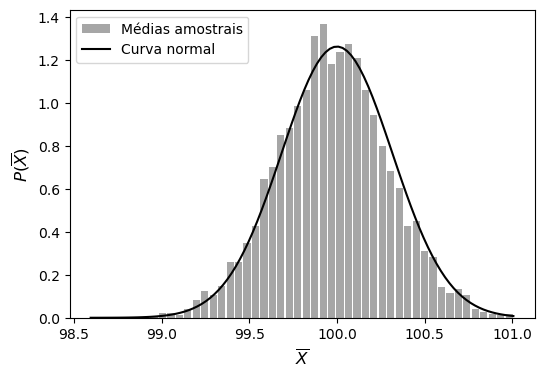

In [1]:
# Pág. 287
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
np.random.seed(101)

# parâmetros da distribuição normal (população)
mu = 100
std = 10
N = 10**6  # tamanho da população
pop = np.random.normal(mu, std, N)

# amostragem
sample_means = []  # armazena as médias amostrais
s = 5000   # número de amostras
n = 1000   # tamanho de cada amostra
for i in range(s):
    sample = np.random.choice(pop, n, replace=True)  
    sample_means.append(np.mean(sample))

# mostra os resultados da simulação
plt.figure(figsize=(6,4))
plt.hist(x=sample_means, bins='auto', color='gray',
         alpha=0.7, rwidth=0.85, density=True, 
         label='Médias amostrais')
plt.xlabel(r'$\overline{X}$', fontsize=12)
plt.ylabel(r'$P(\overline{X})$', fontsize=12)

# curva normal teórica
xmin, xmax = min(sample_means), max(sample_means)
lnspc = np.linspace(xmin, xmax, 100)
pdf_g = stats.norm.pdf(lnspc, mu, std/np.sqrt(n))
plt.plot(lnspc, pdf_g, 
         label="Curva normal", 
         color='black')
plt.legend(fontsize=10)
plt.show()

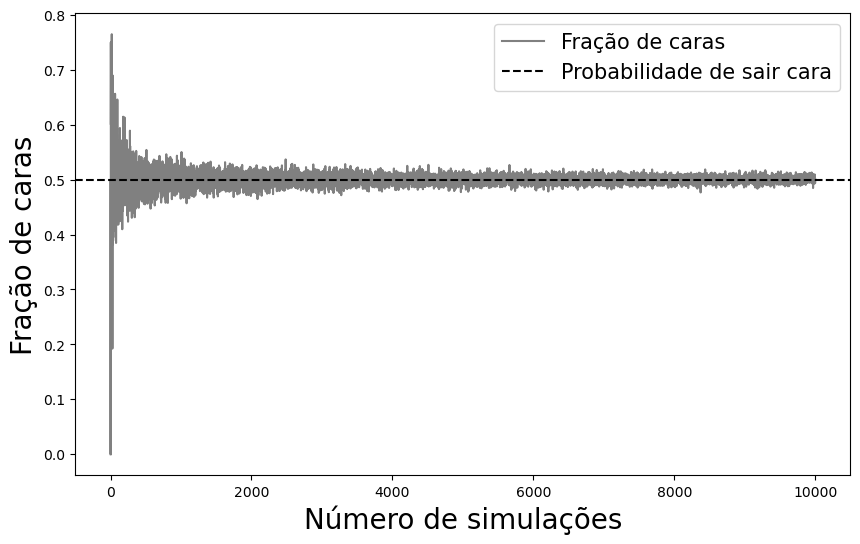

In [2]:
# Pág. 292
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2011)

p = 0.5 # probabilidade de sair cara
Ns = 10000 # número máximo de simulações
vnh = [] # armazena o número de caras
vsim = [] # armazena o número de simulações
for ns in np.arange(1,Ns+1):
    nh = 0 # número de caras
    # realiza ns lançamentos
    for s in range(0,ns):
        # verifica se sai uma cara
        if(np.random.uniform() < p):
            nh = nh+1
    # armazena a probabilidade calculada
    vnh.append(nh/ns)
    vsim.append(ns)
# mostra os resultados
plt.figure(figsize=(10,6))
plt.plot(vsim, vnh, '-', color='gray', 
         label='Fração de caras')
plt.axhline(y=p, color='k', linestyle='--', 
            label = 'Probabilidade de sair cara')
plt.xlabel('Número de simulações', fontsize=20)
plt.ylabel('Fração de caras', fontsize=20)
plt.legend(fontsize = 15)
plt.show(True)

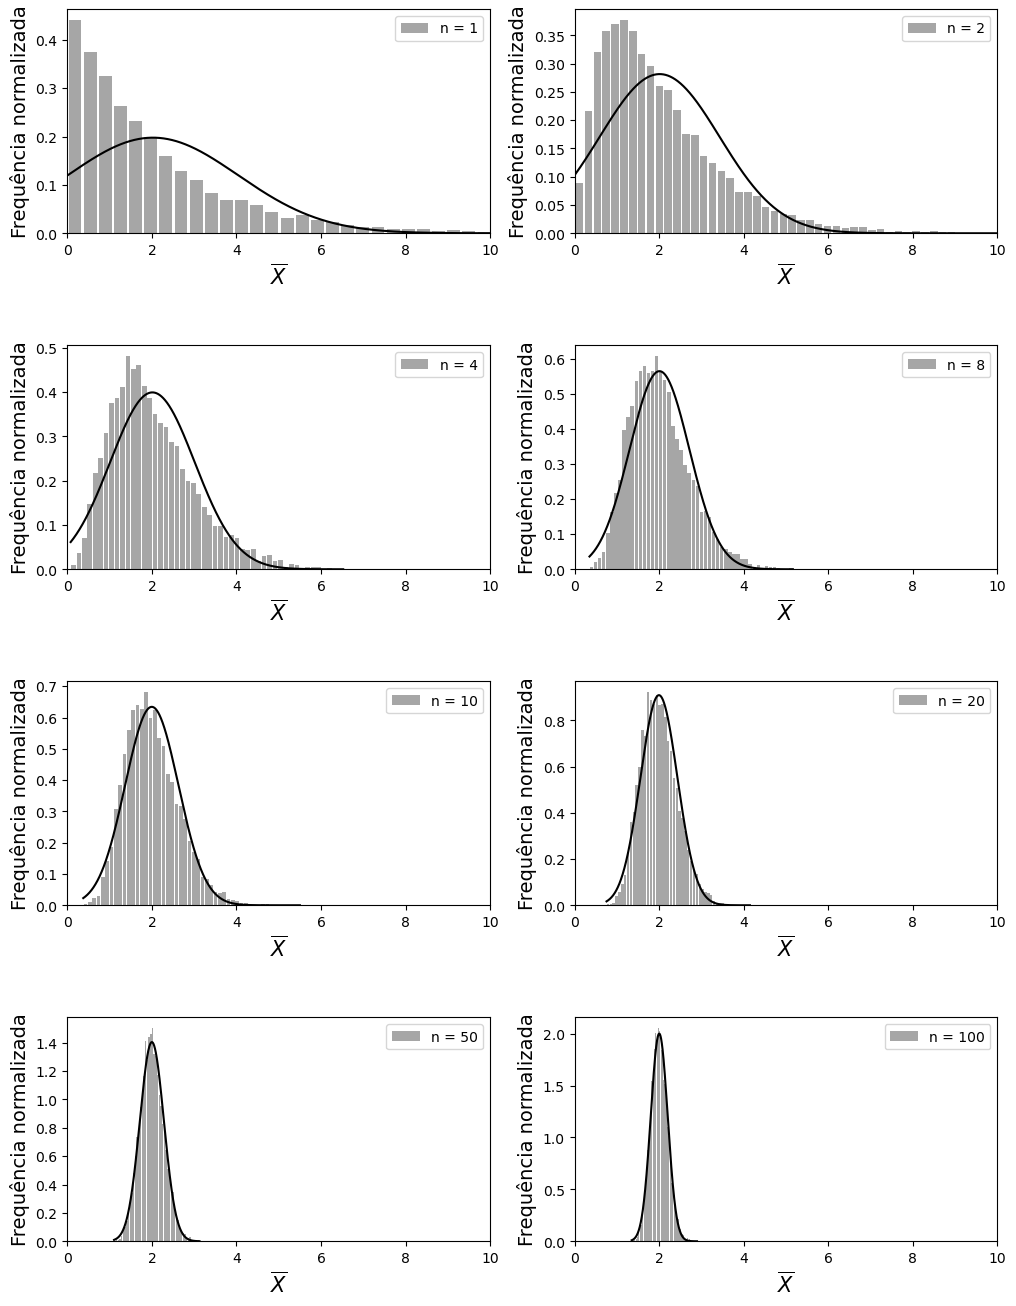

In [3]:
# Pág. 296
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import random
np.random.seed(42)

# número de elementos em cada amostra
vn =  [1, 2 , 4 , 8, 10, 20, 50, 100]
S = 10000 # número de amostras
mu = 2 # média populacional
# gera a população
pop = np.random.exponential(mu, 20000)

plt.figure(figsize=(12,16))
plt.subplots_adjust(hspace=0.5)
aux = 0 # variavel auxiliar
for n in vn: # varia o tamanho da amostra
    vmean = []
    for s in range(0,S): 
        # seleciona s amostras de tamanho n
        X = random.choices(pop,k=n)
        # armazena a média da amostra
        vmean.append(np.mean(X)) 
    # mostra o histograma
    plt.subplot(4, 2, aux + 1)
    aux = aux + 1
    plt.hist(x=vmean, bins=50, color='gray', 
             alpha=0.7, rwidth=0.85, density=True,
             label = 'n = '+str(n))
    plt.xlabel(r'$\overline{X}$', fontsize=15)
    plt.ylabel('Frequência normalizada', fontsize=14)
    plt.legend()
    plt.xlim(0,10)
    # mostra a curva normal ajustada aos dados
    xmin, xmax = min(vmean), max(vmean)  
    lnspc = np.linspace(xmin, xmax, len(vmean))
    m, s = stats.norm.fit(vmean)
    pdf_g = stats.norm.pdf(lnspc, m, s) 
    plt.plot(lnspc, pdf_g, label="Normal", color='black') 
plt.show(True)

In [4]:
# Pág. 301
from IPython.display import display, Math
import scipy.stats as st
import numpy as np
np.random.seed(2011)

# calcula o momento de ordem m
def M(X,P,m):
    En = 0
    for i in range(0, len(X)):
        En = En + (X[i]**m)*P[i]
    return En

# valores de X e P(X=x)
X = [3,6,8]
P = [0.5,0.3,0.2]
E = M(X,P, 1) # valor esperado
E2 = M(X,P, 2) # segundo momento
V = E2 - E**2 # variância
print("Esperança:", M(X,P,1))
print("Variância:",V)

# Cálculo do valor teórico
n = 50 # tamanho da amostra
xbar = 5 # média amostral do problema
z = (xbar-E)/(np.sqrt(V/n))
print('z = ', z)
p = 1-st.norm.cdf(z)
print('Valor teórico:')
display(Math(r'P(\overline{X} >'+str(xbar) +')=' +str(p)))

# realiza a simulação
ns = 1000 # número de simulações
vx = [] # armazena a média amostral
for s in range(0,ns):
    # gera a amostra
    A = np.random.choice(X, n, p=P)
    # armazena a média amostral
    vx.append(np.mean(A))
nmaior = 0 # número de resultados > xbar
for i in range(0, len(vx)):
    # verifica se a média amostral é maior do que xbar
    if(vx[i] > xbar): 
        nmaior = nmaior + 1
freq = nmaior/len(vx)
print('Valor simulado:')
display(Math(r'P(\overline{X} >'+str(xbar) +')=' +str(freq)))

Esperança: 4.9
Variância: 4.089999999999996
z =  0.3496418006375317
Valor teórico:


<IPython.core.display.Math object>

Valor simulado:


<IPython.core.display.Math object>

In [6]:
from IPython.display import display, Math
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

p = 0.7 # probabilidade de sucesso
n = 100 # tamanho da amostra
X = [0,1] # valores de X
P = [1-p,p] # distribuição de probabilidade
px = 0.05 # diferença entre p e a fração de sucessos
ns = 1000 # número de simulações
freq = 0
for s in range(0,ns):
    x = np.random.choice(X, n, p=P)
    if(np.abs(np.mean(x) - p) < px):
        freq = freq + 1
freq = freq/ns
print('Valor simulado:')
display(Math(r'P(|\overline{X} - p| <'+str(px) +')=' +str(freq)))

Valor simulado:


<IPython.core.display.Math object>

In [7]:
# Pág.306
from IPython.display import display, Math
import scipy.stats as st
import numpy as np
np.random.seed(10)

# calcula o momento de ordem n
def M(X,n):
    En = 0
    for i in range(0, len(X)):
        En = En + (X[i]**n)*P[i]
    return En

# valores de X e P(X=x)
X = [10,50,100]
P = [0.4,0.2,0.4]
E = M(X,1) # valor esperado
E2 = M(X,2) # segundo momento
V = E2 - E**2 # variância
print("Esperança:", M(X,1))
print("Variância:",V)

# cálculo do valor teórico
n = 100 # tamanho da amostra
xbar = 60 # média amostral do problema
z = (xbar-E)/(np.sqrt(V/n))
print('z = ', z)
p = st.norm.cdf(z)
print('Valor teórico:')
display(Math(r'P(\overline{X} <'+str(xbar) +')=' +str(p)))

# realiza a simulação
ns = 1000 # número de simulações
vx = [] # armazena a média amostral
for s in range(0,ns):
    # gera a amostra
    A = np.random.choice(X, n, p=P)
    # armazena a média amostral
    vx.append(np.mean(A))
nmaior = 0 # número de resultados > xbar
for i in range(0, len(vx)):
    # verifica se a média amostral < xbar
    if(vx[i] < xbar): 
        nmaior = nmaior + 1
freq = nmaior/len(vx)
print('Valor simulado:')
display(Math(r'P(\overline{X} <'+str(xbar) +')=' +str(freq)))

Esperança: 54.0
Variância: 1624.0
z =  1.4888750009563954
Valor teórico:


<IPython.core.display.Math object>

Valor simulado:


<IPython.core.display.Math object>

In [8]:
# Pág. 308
import scipy.stats as st
import numpy as np

mu = 110 # média
sigma = 20 # desvio padrão
n = 25 # tamanho da amostra
z = (120- mu)/(sigma/np.sqrt(n))
p = 1 - st.norm.cdf(z)
print('Probabilidade:',p)

Probabilidade: 0.006209665325776159
